Simulating Iridium Oxide Lattice...
Simulation Complete. Rendering plot...


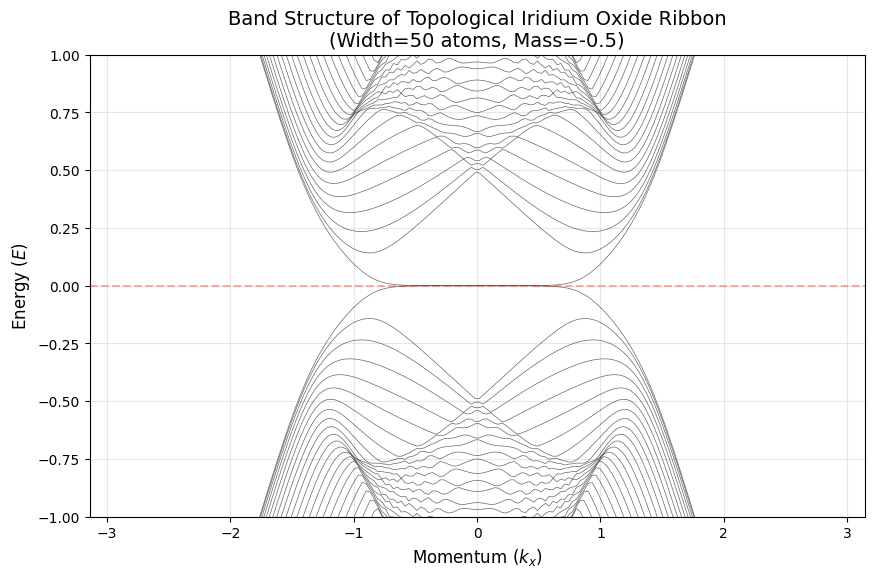

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETERS FOR IRIDIUM OXIDE ---
# We simulate a "ribbon" (infinite length, finite width)
width = 50           # Width of the ribbon in atoms
k_points = 200       # Resolution of the momentum (k)
A = 0.5              # Spin-Orbit Coupling strength (High because of Iridium)
B = 1.0              # Band inversion parameter
M = -0.5             # Mass parameter (Negative M = Topological Phase!)
                     # If M were positive, this would be just a normal insulator (like Emerald)

# Arrays to store the data for plotting
k_values = np.linspace(-np.pi, np.pi, k_points)
energies = []

# --- THE PHYSICS ENGINE ---
print("Simulating Iridium Oxide Lattice...")

for kx in k_values:
    # We build a Hamiltonian Matrix for every momentum point kx
    # The matrix size is 2 * width (because of 2 spin states per site)
    H = np.zeros((2 * width, 2 * width), dtype=complex)
    
    for y in range(width):
        # Index for the current site (2 orbitals per site: Spin Up, Spin Down)
        i = 2 * y
        
        # 1. On-site Energy (The "Mass" term)
        # This includes the band inversion physics (M - 2B)
        epsilon_k = M - 2 * B * (1 - np.cos(kx))
        H[i, i]     =  epsilon_k     # Spin Up
        H[i+1, i+1] = -epsilon_k     # Spin Down
        
        # 2. Hopping between neighbors (y-direction)
        if y < width - 1:
            j = 2 * (y + 1)
            
            # Hopping term (B)
            H[i, j]     = B
            H[j, i]     = B
            H[i+1, j+1] = -B
            H[j+1, i+1] = -B
            
            # Spin-Orbit Coupling term (A) - The "Iridium" effect
            # This mixes the orbitals and creates the topological protection
            H[i, j+1]   = -0.5j * A  # Interaction between Spin Up and Next Site Spin Down
            H[j+1, i]   =  0.5j * A
            H[i+1, j]   = -0.5j * A
            H[j, i+1]   =  0.5j * A

    # 3. Spin-Orbit Coupling in x-direction (added to diagonal)
    # This part depends on kx
    for y in range(width):
        i = 2 * y
        H[i, i+1]   += A * np.sin(kx) # Coupling Spin Up/Down
        H[i+1, i]   += A * np.sin(kx)

    # Solve the matrix for this kx to get allowed energy levels
    eigenvalues = np.linalg.eigvalsh(H)
    energies.append(eigenvalues)

# --- PLOTTING THE RESULT ---
energies = np.array(energies)

plt.figure(figsize=(10, 6))
plt.title(f"Band Structure of Topological Iridium Oxide Ribbon\n(Width={width} atoms, Mass={M})", fontsize=14)
plt.xlabel("Momentum ($k_x$)", fontsize=12)
plt.ylabel("Energy ($E$)", fontsize=12)

# Plot all bands
# The 'X' shape in the middle represents the Conducting Edge States
plt.plot(k_values, energies, color='black', alpha=0.6, linewidth=0.5)

# Highlight the topological gap
plt.axhline(0, color='red', linestyle='--', alpha=0.3, label="Fermi Level")
plt.grid(True, alpha=0.3)
plt.xlim(-np.pi, np.pi)
plt.ylim(-1, 1)

print("Simulation Complete. Rendering plot...")
plt.show()